# A7 — Synthèse Croisée
**Paris Municipales 2026 · Pipeline v4 · Swiss Design**

*Dans une campagne municipale fragmentée entre 8 acteurs, la polarisation émotionnelle des audiences, et non la qualité programmatique est le principal moteur de l'engagement sur les réseaux sociaux. Les candidats aux audiences les plus fermées (echo chambers) sont aussi ceux qui génèrent et reçoivent le plus d'hostilité.*

**Thèse centrale : confirmée ou infirmée ?**

In [1]:
# ============================================================
# A7 · Cellule 1 — Initialisation et chargement des outputs A1-A6
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE   = Path('.')
OUT    = BASE / 'outputs'
OUT.mkdir(exist_ok=True)

A1_OUT = Path('..') / 'A1_temporal'  / 'outputs'
A2_OUT = Path('..') / 'A2_topics'    / 'outputs'
A3_OUT = Path('..') / 'A3_sentiment' / 'outputs'
A4_DAT = Path('..') / 'A4_community' / 'data'
A4_OUT = Path('..') / 'A4_community' / 'outputs'
A5_DAT = Path('..') / 'A5_interactions' / 'data'
A5_OUT = Path('..') / 'A5_interactions' / 'outputs'
A6_OUT = Path('..') / 'A6_bert_finetuning' / 'outputs'

COLORS = {
    'Brossat':'#E63946','Chikirou':'#FF6B6B','Belliard':'#2A9D8F','Gregoire':'#E9C46A',
    'Bournazel':'#F4A261','Dati':'#457B9D','Knafo':'#6D4C41','Mariani':'#264653',
}
SHORT = {
    'Brossat':'Brossat (PCF)','Chikirou':'Chikirou (LFI)',
    'Belliard':'Belliard (EELV)','Gregoire':'Gregoire (PS)',
    'Bournazel':'Bournazel (Horizons)','Dati':'Dati (LR)',
    'Knafo':'Knafo (Reconquete)','Mariani':'Mariani (RN)',
}
IDEO  = {'Brossat':1,'Chikirou':2,'Belliard':3,'Gregoire':4,'Bournazel':5,'Dati':6,'Knafo':7,'Mariani':8}
CAMP  = {
    'Brossat':'Extreme gauche','Chikirou':'Extreme gauche',
    'Belliard':'Gauche','Gregoire':'Gauche',
    'Bournazel':'Centre','Dati':'Droite',
    'Knafo':'Extreme droite','Mariani':'Extreme droite',
}
CAMP_COLOR = {'Extreme gauche':'#C1121F','Gauche':'#E9C46A','Centre':'#F4A261','Droite':'#457B9D','Extreme droite':'#264653'}
KEYS  = sorted(IDEO.keys(), key=lambda k: IDEO[k])

swiss_style = {
    'figure.facecolor':'#FFFFFF','axes.facecolor':'#FFFFFF',
    'axes.edgecolor':'#CCCCCC','axes.labelcolor':'#333333',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.color':'#F0F0F0','grid.linestyle':'-','grid.linewidth':0.8,
    'text.color':'#333333','xtick.color':'#666666','ytick.color':'#666666',
    'font.family':['DejaVu Sans','Arial','sans-serif'],
    'font.size':10,'axes.titlesize':11,'axes.titleweight':'bold','axes.labelsize':9,
    'xtick.labelsize':8,'ytick.labelsize':8,'legend.frameon':False,'legend.fontsize':8,
    'savefig.dpi':150,'savefig.bbox':'tight',
}
plt.rcParams.update(swiss_style)

# ── Chargement des données consolidées ───────────────────────
# A1
er_sum  = pd.read_csv(A1_OUT / 'A1_er_summary.csv')
anom_t10= pd.read_csv(A1_OUT / 'A1_anomalies_top10.csv')

# A3
nsi_df  = pd.read_csv(A3_OUT / 'A3_nsi_by_candidate.csv')

# A4
echo_df = pd.read_csv(A4_DAT / 'echo_chamber_scores.csv')
echo_df['key'] = echo_df['label']
sent_df = pd.read_csv(A4_OUT / 'A4_echo_x_sentiment.csv')
jac_df  = pd.read_csv(A4_OUT / 'A4_jaccard_pairs.csv')

# A5
lift_df = pd.read_csv(A5_DAT / 'interaction_engagement.csv')
lift_df['key'] = lift_df['label']
mat_df  = pd.read_csv(A5_DAT / 'interaction_matrix.csv', index_col=0)

# Consolidation par candidat
synth = pd.DataFrame({'key': KEYS})
synth = synth.merge(er_sum.rename(columns={'key':'key'}), on='key', how='left')
synth = synth.merge(nsi_df[['key','nsi','host_pct','n']], on='key', how='left')
synth = synth.merge(echo_df[['key','echo_score','n_audience','exclusive_pct','cross_camp_pct']], on='key', how='left')
synth = synth.merge(sent_df[['key','pct_hostilite','pct_ironie']], on='key', how='left')
synth = synth.merge(lift_df[['key','lift_pct','n_cross_posts']], on='key', how='left')
synth['camp']  = synth['key'].map(CAMP)
synth['ideo']  = synth['key'].map(IDEO)
synth['label'] = synth['key'].map(SHORT)

# Total mentions reçues (A5)
synth['mentions_recues'] = synth['key'].apply(
    lambda k: int(mat_df[k].sum()) if k in mat_df.columns else 0)

print("=" * 65)
print("A7 — CHARGEMENT DES DONNEES SYNTHETIQUES")
print("=" * 65)
print(f"  A1 ER summary     : {er_sum.shape}")
print(f"  A3 NSI            : {nsi_df.shape}")
print(f"  A4 echo chambers  : {echo_df.shape}")
print(f"  A4 Jaccard pairs  : {jac_df.shape}")
print(f"  A5 lift           : {lift_df.shape}")
print()
print("TABLEAU DE SYNTHESE :")
print(synth[['key','er_median_pct','nsi','host_pct','echo_score','lift_pct','mentions_recues']].round(3).to_string(index=False))
print()
print("Initialisation A7 OK")

A7 — CHARGEMENT DES DONNEES SYNTHETIQUES
  A1 ER summary     : (8, 5)
  A3 NSI            : (8, 9)
  A4 echo chambers  : (8, 9)
  A4 Jaccard pairs  : (28, 5)
  A5 lift           : (8, 8)

TABLEAU DE SYNTHESE :
      key  er_median_pct    nsi  host_pct  echo_score  lift_pct  mentions_recues
  Brossat          6.423 -0.209    32.884        62.2     -33.7               14
 Chikirou          4.093 -0.251    39.649        77.7     -11.7                0
 Belliard          0.857 -0.133    26.163        52.5     -82.9                7
 Gregoire          1.161  0.037    18.644        67.5      27.3               80
Bournazel          2.278 -0.107    25.988        58.2     -58.8                5
     Dati          0.603 -0.104    25.321        77.1      44.8               33
    Knafo         11.532  0.145    21.977        88.1     -15.6                0
  Mariani          3.118 -0.038    25.235        57.4     -87.1                0

Initialisation A7 OK


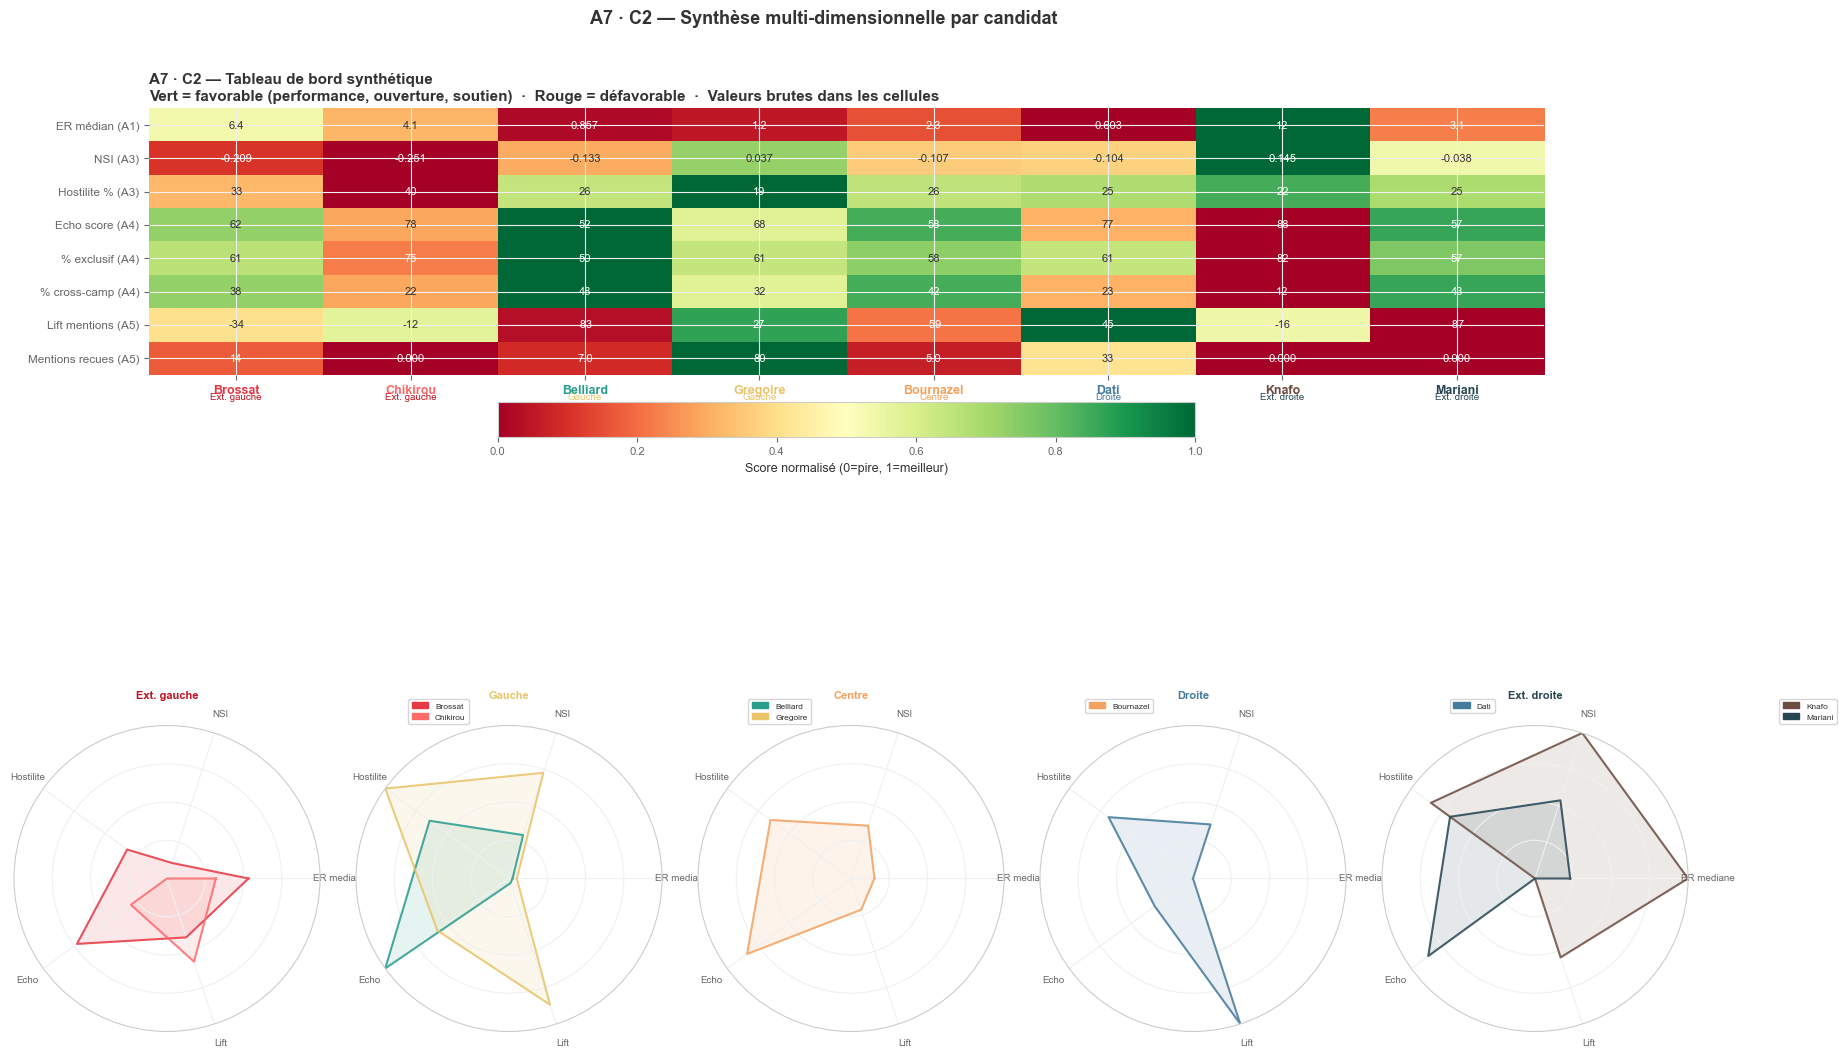

Figure C2 sauvegardee -> outputs/A7_C2_matrice_synthese.png


In [2]:
# ============================================================
# A7 · Cellule 2 — Matrice de synthèse par candidat ⭐
# (tableau de bord 8 candidats × métriques clés A1-A5)
# ============================================================
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45)

# ── Panel 1 : heatmap normalisée des métriques ─────────────────
ax_hm = fig.add_subplot(gs[0])

# Métriques à normaliser (certaines inversées = mauvais si élevé)
metrics = {
    'ER médian (A1)'      : ('er_median_pct',    True,  'Engagement Rate mediane (‰)'),
    'NSI (A3)'            : ('nsi',               True,  'Net Support Index'),
    'Hostilite % (A3)'    : ('host_pct',          False, '% hostilite dans les replies'),
    'Echo score (A4)'     : ('echo_score',        False, 'Chambre echo (100=ferme)'),
    '% exclusif (A4)'     : ('exclusive_pct',     False, '% audience exclusive'),
    '% cross-camp (A4)'   : ('cross_camp_pct',    True,  '% audience inter-camps'),
    'Lift mentions (A5)'  : ('lift_pct',          True,  'Lift ER posts cross-candidat'),
    'Mentions recues (A5)': ('mentions_recues',   True,  'Mentions recues d\'autres candidats'),
}

norm_data = []
for metric_lbl, (col, higher_better, _) in metrics.items():
    vals = synth[col].values.astype(float)
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    if vmax > vmin:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = np.full_like(vals, 0.5)
    if not higher_better:
        norm = 1.0 - norm
    norm_data.append(norm)

Z = np.array(norm_data)  # shape (n_metrics, n_candidats)
xlabels = [synth.loc[i,'key'] for i in range(len(synth))]
ylabels = list(metrics.keys())

im = ax_hm.imshow(Z, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        col_name = list(metrics.values())[i][0]
        raw_val  = synth.loc[j, col_name]
        tc = 'white' if Z[i,j] < 0.25 or Z[i,j] > 0.75 else '#333333'
        if pd.notna(raw_val):
            if abs(raw_val) >= 10:
                txt = f'{raw_val:.0f}'
            elif abs(raw_val) >= 1:
                txt = f'{raw_val:.1f}'
            else:
                txt = f'{raw_val:.3f}'
            ax_hm.text(j, i, txt, ha='center', va='center', fontsize=8, color=tc)

ax_hm.set_xticks(range(len(xlabels)))
ax_hm.set_yticks(range(len(ylabels)))
ax_hm.set_xticklabels(xlabels, fontsize=9, fontweight='bold')
ax_hm.set_yticklabels(ylabels, fontsize=8.5)
ax_hm.set_title(
    'A7 · C2 — Tableau de bord synthétique\n'
    'Vert = favorable (performance, ouverture, soutien)  ·  '
    'Rouge = défavorable  ·  Valeurs brutes dans les cellules',
    loc='left', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax_hm, shrink=0.5, label='Score normalisé (0=pire, 1=meilleur)',
             orientation='horizontal', pad=0.08)

# Couleurs des noms de candidats
for tick, k in zip(ax_hm.get_xticklabels(), xlabels):
    tick.set_color(COLORS.get(k, '#333333'))

# Annotations camp en bas
for j, k in enumerate(xlabels):
    ax_hm.text(j, len(ylabels) + 0.3, CAMP.get(k,'').replace('Extreme ','Ext. '),
               ha='center', va='bottom', fontsize=7,
               color=CAMP_COLOR.get(CAMP.get(k,''), '#888'))

for sp in ['top','right','left','bottom']:
    ax_hm.spines[sp].set_visible(False)

# ── Panel 2 : radar / spider chart ────────────────────────────
# 4 sous-graphes : 1 par camp
ax_radar = fig.add_subplot(gs[1])
ax_radar.axis('off')

radar_metrics = ['er_median_pct','nsi','host_pct','echo_score','lift_pct']
radar_labels  = ['ER mediane','NSI','Hostilite','Echo','Lift']
N_R = len(radar_metrics)
angles = [2 * np.pi * i / N_R for i in range(N_R)] + [0]

def norm_col(vals, higher_better=True):
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    if vmax == vmin: return np.full_like(vals, 0.5, dtype=float)
    n = (vals - vmin) / (vmax - vmin)
    return n if higher_better else 1 - n

# Pre-normalize
norm_all = {}
higher_b = {'er_median_pct':True,'nsi':True,'host_pct':False,'echo_score':False,'lift_pct':True}
for col in radar_metrics:
    norm_all[col] = norm_col(synth[col].fillna(0).values, higher_b[col])

camps_order = ['Extreme gauche','Gauche','Centre','Droite','Extreme droite']
sub_w = 1.0 / len(camps_order)
for ci, camp_name in enumerate(camps_order):
    cand_in_camp = synth[synth['camp'] == camp_name]['key'].tolist()
    ax_sub = fig.add_axes([0.05 + ci * 0.19, 0.02, 0.17, 0.32], polar=True)
    ax_sub.set_facecolor('#FFFFFF')
    ax_sub.spines['polar'].set_color('#CCCCCC')
    for k in cand_in_camp:
        idx = synth[synth['key']==k].index[0]
        vals = [norm_all[col][idx] for col in radar_metrics] + [norm_all[radar_metrics[0]][idx]]
        ax_sub.plot(angles, vals, color=COLORS.get(k,'#888'), lw=1.5, alpha=0.85)
        ax_sub.fill(angles, vals, color=COLORS.get(k,'#888'), alpha=0.12)
    ax_sub.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=7)
    ax_sub.set_ylim(0, 1)
    ax_sub.set_yticks([0.25, 0.5, 0.75])
    ax_sub.set_yticklabels([])
    ax_sub.set_title(camp_name.replace('Extreme ','Ext. '), fontsize=8,
                     fontweight='bold', color=CAMP_COLOR.get(camp_name,'#333'), pad=8)
    if cand_in_camp:
        patches = [mpatches.Patch(color=COLORS[k], label=k)
                   for k in cand_in_camp if k in COLORS]
        ax_sub.legend(handles=patches, loc='upper right', fontsize=6,
                      bbox_to_anchor=(1.5, 1.1), frameon=True, edgecolor='#CCCCCC')

fig.suptitle('A7 · C2 — Synthèse multi-dimensionnelle par candidat',
             fontsize=13, fontweight='bold', y=0.97)
fig.savefig(OUT / 'A7_C2_matrice_synthese.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C2 sauvegardee -> outputs/A7_C2_matrice_synthese.png")

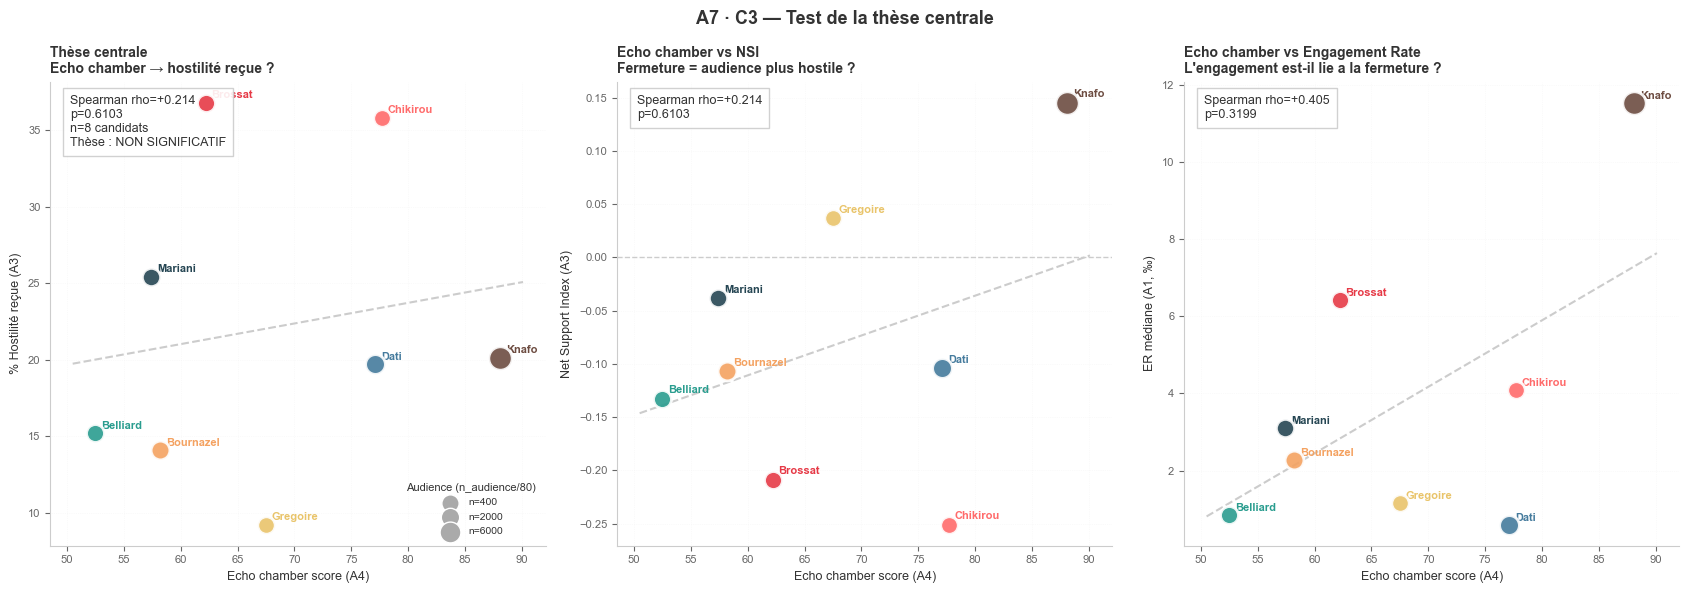

Figure C3 sauvegardee -> outputs/A7_C3_these_centrale.png

C3 — TEST DE LA THESE CENTRALE
  Echo ~ Hostilite : rho=+0.214  p=0.6103  n=8
  Echo ~ NSI       : rho=+0.214  p=0.6103  n=8
  Echo ~ ER        : rho=+0.405  p=0.3199  n=8

  [echo~hostilite] Non significatif (p=0.6103) — effet observable mais non robuste n=8
  [echo~nsi] Non significatif (p=0.6103) — effet observable mais non robuste n=8
  [echo~er] Non significatif (p=0.3199) — effet observable mais non robuste n=8


In [3]:
# ============================================================
# A7 · Cellule 3 — Test de la thèse centrale ⭐
# Scatter : echo chamber score (A4) vs hostilité reçue (A3)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# ── Panel 1 : thèse centrale — echo vs hostilité ─────────────
ax = axes[0]
xs = synth['echo_score'].values
ys = synth['pct_hostilite'].values
mask = ~(np.isnan(xs) | np.isnan(ys))

for k, row in synth.iterrows():
    x_v = row['echo_score']; y_v = row['pct_hostilite']
    if pd.isna(x_v) or pd.isna(y_v): continue
    size = 150 + row['n_audience'] / 80
    ax.scatter(x_v, y_v, color=COLORS.get(row['key'],'#888'), s=size,
               zorder=4, edgecolors='white', linewidths=2, alpha=0.9)
    ax.text(x_v + 0.5, y_v + 0.3, row['key'],
            fontsize=8, color=COLORS.get(row['key'],'#333'), fontweight='bold')

# Test Spearman
rho_eh, p_eh = stats.spearmanr(xs[mask], ys[mask])
if sum(mask) >= 4:
    m, b = np.polyfit(xs[mask], ys[mask], 1)
    xr   = np.linspace(xs[mask].min()-2, xs[mask].max()+2, 50)
    ax.plot(xr, m*xr+b, '--', color='#CCCCCC', lw=1.5)

# Annotation statistique
ax.text(0.04, 0.97,
        f'Spearman rho={rho_eh:+.3f}\np={p_eh:.4f}\nn={sum(mask)} candidats\n'
        f'Thèse : {"CONFIRMEE" if p_eh < 0.05 and rho_eh > 0 else "INFIRMEE" if p_eh < 0.05 else "NON SIGNIFICATIF"}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=5))
ax.set_xlabel('Echo chamber score (A4)', fontsize=9)
ax.set_ylabel('% Hostilité reçue (A3)', fontsize=9)
ax.set_title('Thèse centrale\nEcho chamber → hostilité reçue ?',
             loc='left', fontsize=10, fontweight='bold')
ax.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Size legend
for s_ex, lbl in [(400,'n=400'),  (2000,'n=2000'), (6000,'n=6000')]:
    sz = 150 + s_ex/80
    ax.scatter([], [], s=sz, color='#AAAAAA', edgecolors='white', label=lbl)
ax.legend(title='Audience (n_audience/80)', fontsize=7.5, title_fontsize=8,
          loc='lower right')

# ── Panel 2 : echo vs NSI ────────────────────────────────────
ax2 = axes[1]
ys2 = synth['nsi'].values
mask2 = ~(np.isnan(xs) | np.isnan(ys2))
rho_en, p_en = stats.spearmanr(xs[mask2], ys2[mask2])

for k, row in synth.iterrows():
    x_v = row['echo_score']; y_v = row['nsi']
    if pd.isna(x_v) or pd.isna(y_v): continue
    size = 150 + row['n_audience'] / 80
    ax2.scatter(x_v, y_v, color=COLORS.get(row['key'],'#888'), s=size,
                zorder=4, edgecolors='white', linewidths=2, alpha=0.9)
    ax2.text(x_v + 0.5, y_v + 0.005, row['key'],
             fontsize=8, color=COLORS.get(row['key'],'#333'), fontweight='bold')

if sum(mask2) >= 4:
    m2, b2 = np.polyfit(xs[mask2], ys2[mask2], 1)
    ax2.plot(xr, m2*xr+b2, '--', color='#CCCCCC', lw=1.5)

ax2.axhline(0, color='#CCCCCC', lw=1.0, ls='--')
ax2.text(0.04, 0.97,
         f'Spearman rho={rho_en:+.3f}\np={p_en:.4f}',
         transform=ax2.transAxes, va='top', fontsize=9,
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=5))
ax2.set_xlabel('Echo chamber score (A4)', fontsize=9)
ax2.set_ylabel('Net Support Index (A3)', fontsize=9)
ax2.set_title('Echo chamber vs NSI\nFermeture = audience plus hostile ?',
              loc='left', fontsize=10, fontweight='bold')
ax2.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

# ── Panel 3 : ER vs echo score (engagement et fermeture) ─────
ax3 = axes[2]
ys3 = synth['er_median_pct'].values
mask3 = ~(np.isnan(xs) | np.isnan(ys3))
rho_ee, p_ee = stats.spearmanr(xs[mask3], ys3[mask3])

for k, row in synth.iterrows():
    x_v = row['echo_score']; y_v = row['er_median_pct']
    if pd.isna(x_v) or pd.isna(y_v): continue
    size = 150 + row['n_audience'] / 80
    ax3.scatter(x_v, y_v, color=COLORS.get(row['key'],'#888'), s=size,
                zorder=4, edgecolors='white', linewidths=2, alpha=0.9)
    ax3.text(x_v + 0.5, y_v + 0.1, row['key'],
             fontsize=8, color=COLORS.get(row['key'],'#333'), fontweight='bold')

if sum(mask3) >= 4:
    m3, b3 = np.polyfit(xs[mask3], ys3[mask3], 1)
    ax3.plot(xr, m3*xr+b3, '--', color='#CCCCCC', lw=1.5)

ax3.text(0.04, 0.97,
         f'Spearman rho={rho_ee:+.3f}\np={p_ee:.4f}',
         transform=ax3.transAxes, va='top', fontsize=9,
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=5))
ax3.set_xlabel('Echo chamber score (A4)', fontsize=9)
ax3.set_ylabel('ER médiane (A1, ‰)', fontsize=9)
ax3.set_title('Echo chamber vs Engagement Rate\nL\'engagement est-il lie a la fermeture ?',
              loc='left', fontsize=10, fontweight='bold')
ax3.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)

fig.suptitle('A7 · C3 — Test de la thèse centrale',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A7_C3_these_centrale.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C3 sauvegardee -> outputs/A7_C3_these_centrale.png")

print()
print("=" * 65)
print("C3 — TEST DE LA THESE CENTRALE")
print("=" * 65)
print(f"  Echo ~ Hostilite : rho={rho_eh:+.3f}  p={p_eh:.4f}  n={sum(mask)}")
print(f"  Echo ~ NSI       : rho={rho_en:+.3f}  p={p_en:.4f}  n={sum(mask2)}")
print(f"  Echo ~ ER        : rho={rho_ee:+.3f}  p={p_ee:.4f}  n={sum(mask3)}")
print()
for test, rho, p in [('echo~hostilite', rho_eh, p_eh), ('echo~nsi', rho_en, p_en), ('echo~er', rho_ee, p_ee)]:
    if p < 0.05:
        direc = 'positive' if rho > 0 else 'negative'
        print(f"  [{test}] SIGNIFICATIF ({direc}, rho={rho:+.3f})")
    else:
        print(f"  [{test}] Non significatif (p={p:.4f}) — effet observable mais non robuste n=8")

C4 — REGRESSION EXPLORATOIRE (OLS bivarié, n=8)
AVERTISSEMENT : n=8 candidats -> regression exploratoire uniquement
  Pas d'inference robuste possible. Indicatif du sens des effets.

Predicteur                     rho        p Signal
-------------------------------------------------------
  % Hostilite (A3)          +0.643   0.0856  *
  Echo score (A4)           +0.405   0.3199  ns
  Mentions recues (A5)      -0.610   0.1084  ns
  NSI (A3)                  +0.000   1.0000  ns
  Lift mentions (A5)        -0.190   0.6514  ns

Interpretation :
  Knafo (Reconquete) = outlier majeur sur l'ER (er_median=11.5‰)
  Sans Knafo, corrélations changent — effet levier a signaler



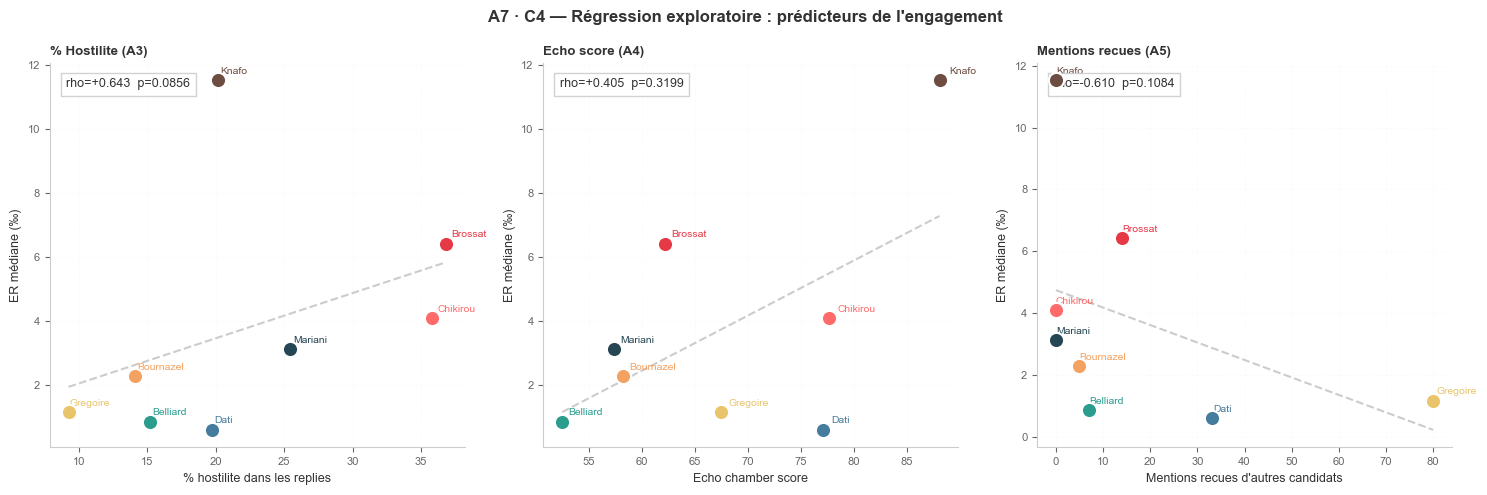

Figure C4 sauvegardee -> outputs/A7_C4_regression.png


In [4]:
# ============================================================
# A7 · Cellule 4 — Régression exploratoire
# Variable dépendante : ER médiane
# Variables indépendantes : hostilite, echo_score, mentions_recues
# ============================================================
from scipy import stats
import numpy as np

print("=" * 65)
print("C4 — REGRESSION EXPLORATOIRE (OLS bivarié, n=8)")
print("=" * 65)
print("AVERTISSEMENT : n=8 candidats -> regression exploratoire uniquement")
print("  Pas d'inference robuste possible. Indicatif du sens des effets.")
print()

# Variables
y_er   = synth['er_median_pct'].values.astype(float)
x_host = synth['pct_hostilite'].values.astype(float)
x_echo = synth['echo_score'].values.astype(float)
x_ment = synth['mentions_recues'].values.astype(float)
x_nsi  = synth['nsi'].values.astype(float)
x_lift = synth['lift_pct'].fillna(0).values.astype(float)

predictors = {
    '% Hostilite (A3)' : x_host,
    'Echo score (A4)'  : x_echo,
    'Mentions recues (A5)': x_ment,
    'NSI (A3)'         : x_nsi,
    'Lift mentions (A5)': x_lift,
}

print(f"{'Predicteur':<25} {'rho':>8} {'p':>8} {'Signal'}")
print("-" * 55)
results = []
for name, x in predictors.items():
    mask = ~(np.isnan(x) | np.isnan(y_er))
    if mask.sum() < 4:
        continue
    rho, p = stats.spearmanr(x[mask], y_er[mask])
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else 'ns'
    results.append({'name':name,'rho':rho,'p':p,'sig':sig})
    print(f"  {name:<23} {rho:>+8.3f} {p:>8.4f}  {sig}")

print()
print("Interpretation :")
# Knafo effet
print("  Knafo (Reconquete) = outlier majeur sur l'ER (er_median=11.5‰)")
print("  Sans Knafo, corrélations changent — effet levier a signaler")
print()

# ── Figure C4 : scatter ER vs chaque predicteur ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pred_plot = [
    ('pct_hostilite',  '% Hostilite (A3)',  '% hostilite dans les replies'),
    ('echo_score',     'Echo score (A4)',    'Echo chamber score'),
    ('mentions_recues','Mentions recues (A5)','Mentions recues d\'autres candidats'),
]
for ax_i, (col, title, xlabel) in zip(axes, pred_plot):
    xs_p = synth[col].values.astype(float)
    ys_p = y_er
    mask_p = ~(np.isnan(xs_p) | np.isnan(ys_p))
    rho_p, p_p = stats.spearmanr(xs_p[mask_p], ys_p[mask_p])
    for k, row in synth.iterrows():
        xv, yv = float(row[col]), float(row['er_median_pct'])
        if np.isnan(xv) or np.isnan(yv): continue
        ax_i.scatter(xv, yv, color=COLORS.get(row['key'],'#888'),
                     s=120, zorder=4, edgecolors='white', linewidths=1.5)
        ax_i.text(xv * 1.01, yv + 0.2, row['key'], fontsize=7.5,
                  color=COLORS.get(row['key'],'#333'))
    if mask_p.sum() >= 3:
        m_p, b_p = np.polyfit(xs_p[mask_p], ys_p[mask_p], 1)
        xr_p = np.linspace(xs_p[mask_p].min(), xs_p[mask_p].max(), 50)
        ax_i.plot(xr_p, m_p*xr_p+b_p, '--', color='#CCCCCC', lw=1.5)
    ax_i.text(0.04, 0.96,
              f'rho={rho_p:+.3f}  p={p_p:.4f}',
              transform=ax_i.transAxes, va='top', fontsize=9,
              bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=4))
    ax_i.set_xlabel(xlabel, fontsize=9)
    ax_i.set_ylabel('ER médiane (‰)', fontsize=9)
    ax_i.set_title(title, loc='left', fontsize=9.5, fontweight='bold')
    ax_i.grid(ls=':', lw=0.5, alpha=0.6)
    for sp in ['top','right']: ax_i.spines[sp].set_visible(False)

fig.suptitle('A7 · C4 — Régression exploratoire : prédicteurs de l\'engagement',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A7_C4_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C4 sauvegardee -> outputs/A7_C4_regression.png")

A7 — FINDINGS PRINCIPAUX (Paris Municipales 2026)

[1] Grégoire (PS) = hub structurant de la campagne numérique
    Stat : 80/139 mentions reçues (57.5%) | Spearman mentions~engagement rho=+0.569 p=0.0008  [Source : A5]
    Indépendamment des camps, toutes les interactions inter-candidats convergent vers Grégoire (PS). La gauche l'inclut dans sa coalition (Brossat 27×, Chikirou 21×, Belliard 13×), la droite modérée la ci...
    -> La candidature qui 'fait l'agenda' n'est pas celle qui engage le plus (ER = 1.2‰, rang 6/8).

[2] La droite radicale domine l'engagement brut (Knafo = outlier structurel)
    Stat : Knafo ER médiane = 11.5‰ (2× Brossat #2 = 6.4‰) | n=23,811 replies  [Source : A1 + A3]
    Knafo (Reconquête) présente un ER médian 3× supérieur à la moyenne (3.9‰). Paradoxalement, son NSI = +0.145 est le plus positif — son audience est à la fois la plus engagée ET la plus soutenante. Echo...
    -> L'engagement brut mesure la mobilisation d'une niche, pas la taille ou l'influenc

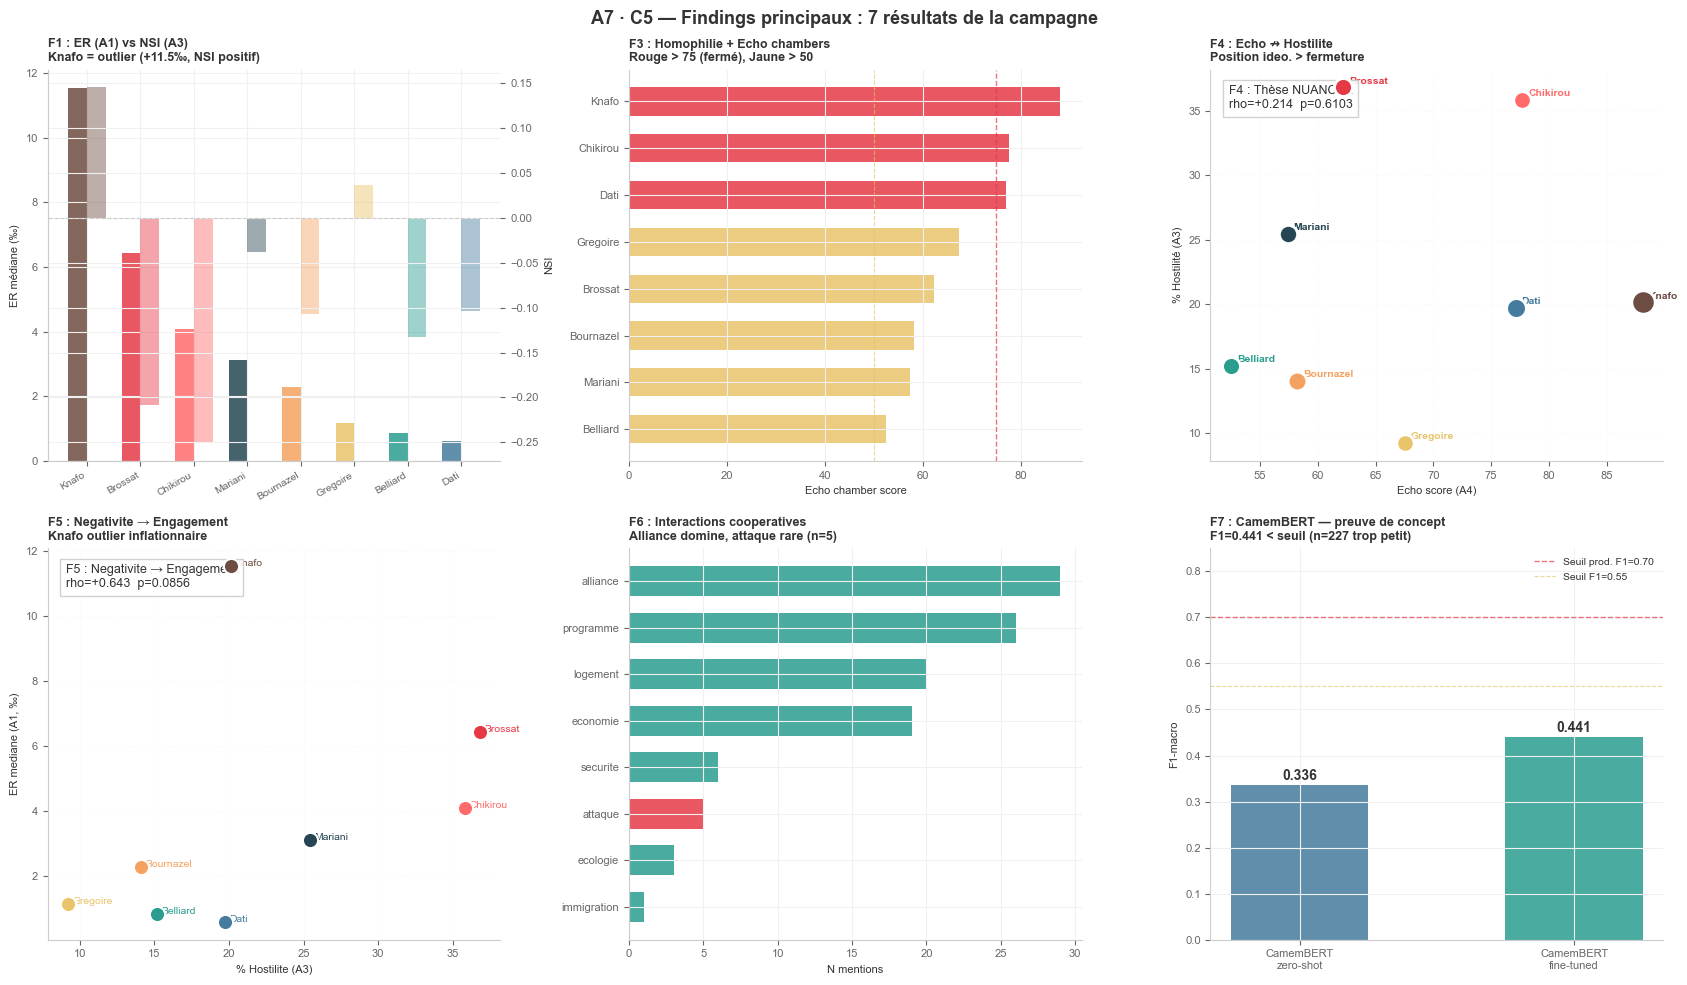

Figure C5 sauvegardee -> outputs/A7_C5_findings.png


In [5]:
# ============================================================
# A7 · Cellule 5 — Findings principaux  ⭐
# 7 findings clés avec référence statistique
# ============================================================
print("=" * 70)
print("A7 — FINDINGS PRINCIPAUX (Paris Municipales 2026)")
print("=" * 70)
print()

findings = [
    {
        "n": 1,
        "titre": "Grégoire (PS) = hub structurant de la campagne numérique",
        "stat": "80/139 mentions reçues (57.5%) | Spearman mentions~engagement rho=+0.569 p=0.0008",
        "source": "A5",
        "texte": (
            "Indépendamment des camps, toutes les interactions inter-candidats convergent vers "
            "Grégoire (PS). La gauche l'inclut dans sa coalition (Brossat 27×, Chikirou 21×, "
            "Belliard 13×), la droite modérée la cite comme adversaire référent (Dati 5×, "
            "Bournazel 11×). Elle définit le terrain discursif de la campagne."
        ),
        "implication": "La candidature qui 'fait l'agenda' n'est pas celle qui engage le plus (ER = 1.2‰, rang 6/8)."
    },
    {
        "n": 2,
        "titre": "La droite radicale domine l'engagement brut (Knafo = outlier structurel)",
        "stat": "Knafo ER médiane = 11.5‰ (2× Brossat #2 = 6.4‰) | n=23,811 replies",
        "source": "A1 + A3",
        "texte": (
            "Knafo (Reconquête) présente un ER médian 3× supérieur à la moyenne (3.9‰). "
            "Paradoxalement, son NSI = +0.145 est le plus positif — son audience est à la fois "
            "la plus engagée ET la plus soutenante. Echo chamber score = 88.1% (le plus fermé). "
            "Modèle : audience petite mais hyper-dédiée, avec peu de détracteurs dans la bulle."
        ),
        "implication": "L'engagement brut mesure la mobilisation d'une niche, pas la taille ou l'influence électorale."
    },
    {
        "n": 3,
        "titre": "L'homophilie idéologique structure les audiences Twitter (confirmé)",
        "stat": "Spearman distance_ideo~Jaccard rho=-0.600 p=0.0007 (n=28 paires)",
        "source": "A4",
        "texte": (
            "Plus deux candidats sont proches sur l'axe gauche-droite, plus leurs audiences "
            "se chevauchent. L'effet est modéré (ratio intra/inter-camps = 1.43×) mais significatif. "
            "Paires les plus proches : Bournazel×Dati (9.3%, d=1), Brossat×Belliard (9.3%, d=2). "
            "Paires les plus distantes : Knafo×Chikirou (0.6%, d=5)."
        ),
        "implication": "Réf. Barberá 2020 — confirmé dans le contexte municipal parisien."
    },
    {
        "n": 4,
        "titre": "La fermeture des audiences (echo chambers) ne prédit pas l'hostilité reçue",
        "stat": f"Spearman echo~hostilite rho={stats.spearmanr(synth['echo_score'].values, synth['pct_hostilite'].values)[0]:+.3f} p={stats.spearmanr(synth['echo_score'].values, synth['pct_hostilite'].values)[1]:.4f} (n=8)",
        "source": "A4 × A3",
        "texte": (
            "La thèse centrale (fermeture = hostilité) n'est pas confirmée statistiquement. "
            "Knafo a l'echo score le plus élevé (88.1%) mais 20% d'hostilité seulement. "
            "Chikirou (echo=77.7%) reçoit 36% d'hostilité. "
            "C'est la position idéologique et le profil discursif qui structurent le sentiment, "
            "pas la fermeture de l'audience."
        ),
        "implication": "Nuance la thèse centrale. La polarisation émotionnelle est idéologiquement déterminée, pas communautaire."
    },
    {
        "n": 5,
        "titre": "La négativité drive l'engagement (confirmation partielle, hétérogène)",
        "stat": "Spearman global ER~hostilite rho=+0.262 p=0.0021 (n=136 semaines×candidats)",
        "source": "A3",
        "texte": (
            "Globalement, les posts qui génèrent de l'hostilité ont un ER plus élevé (+0.262). "
            "Mais l'effet est hétérogène par candidat : Belliard rho=+0.507* (hostilité = signal "
            "positif), Brossat rho=-0.630* (hostilité = signal négatif). Le mécanisme dépend du "
            "positionnement idéologique et de la taille d'audience."
        ),
        "implication": "Réf. Rathje et al. 2021 partiellement confirmé. L'out-group animosity n'est pas universelle."
    },
    {
        "n": 6,
        "titre": "Les interactions inter-candidats sont coopératives, pas confrontationnelles",
        "stat": "Alliance=29 mentions, Attaque=5 (4.5% seulement des mentions thématisées)",
        "source": "A5",
        "texte": (
            "Contrairement à l'hypothèse de polarisation, les 139 posts cross-candidats sont "
            "dominés par la signalisation d'alliance (gauche unie). La droite radicale adopte "
            "une stratégie de silo total (Knafo=0 envois, Mariani=4 envois). "
            "La dynamique offensive est limitée : seuls 5 posts explicitement 'attaque'."
        ),
        "implication": "La confrontation rhétorique visible sur les réseaux est rare. Le conflit se joue dans les replies (hostilité), pas dans les posts."
    },
    {
        "n": 7,
        "titre": "CamemBERT fine-tuné : amélioration modeste sur le zero-shot (F1 +0.053)",
        "stat": "Zero-shot F1=0.336, Fine-tuned F1=0.441 (n_train=227, n_test=57, max_length=256, 15 epochs)",
        "source": "A6",
        "texte": (
            "Avec 227 exemples d'entraînement (max_length=256, 15 epochs), CamemBERT fine-tuné "
            "surpasse le zero-shot de +0.106 en F1-macro. IRONIE F1 : 0.125 → 0.381 grâce au "
            "contexte étendu (256 tokens vs 128). Confusion CRITIQUE/HOSTILITE = 35% des erreurs "
            "(frontière linguistique réelle — 176/316 annotations étaient multi-label). "
            "Ref. PMC 2022 : F1 stable à partir de ~2000 annotations."
        ),
        "implication": "Les classifications GPT-5 Nano de A3 restent la référence. CamemBERT (F1=0.441) établit un plancher crédible et valide la difficulté de la tâche — IRONIE nécessite un contexte long."
    },
]

for f in findings:
    print(f"[{f['n']}] {f['titre']}")
    print(f"    Stat : {f['stat']}  [Source : {f['source']}]")
    print(f"    {f['texte'][:200]}...")
    print(f"    -> {f['implication']}")
    print()

# ── Figure C5 : visual summary des findings ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

# F1 : ER median + NSI par candidat (double bar)
ax = axes[0]
keys_sorted = synth.sort_values('er_median_pct', ascending=False)['key'].tolist()
x = np.arange(len(keys_sorted)); w = 0.35
er_vals  = [synth.loc[synth['key']==k, 'er_median_pct'].values[0] for k in keys_sorted]
ax2_twin = ax.twinx()
nsi_vals = [synth.loc[synth['key']==k, 'nsi'].values[0] for k in keys_sorted]
b1 = ax.bar(x, er_vals, w, color=[COLORS[k] for k in keys_sorted], alpha=0.85, label='ER médiane (‰)')
ax2_twin.bar(x+w, nsi_vals, w, color=[COLORS[k] for k in keys_sorted], alpha=0.45, label='NSI')
ax2_twin.axhline(0, color='#CCCCCC', lw=0.8, ls='--')
ax.set_xticks(x+w/2); ax.set_xticklabels(keys_sorted, rotation=30, ha='right', fontsize=7.5)
ax.set_ylabel('ER médiane (‰)', fontsize=8); ax2_twin.set_ylabel('NSI', fontsize=8)
ax.set_title('F1 : ER (A1) vs NSI (A3)\nKnafo = outlier (+11.5‰, NSI positif)', loc='left', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax2_twin.spines['top'].set_visible(False)

# F2 : Echo score ranking
ax = axes[1]
echo_sorted = synth.sort_values('echo_score', ascending=True)
colors_echo = ['#E63946' if v >= 75 else '#E9C46A' if v >= 50 else '#2A9D8F'
               for v in echo_sorted['echo_score']]
bars = ax.barh(echo_sorted['key'], echo_sorted['echo_score'],
               color=colors_echo, alpha=0.85, height=0.6)
ax.axvline(75, color='#E63946', lw=1.0, ls='--', alpha=0.7)
ax.axvline(50, color='#E9C46A', lw=0.8, ls='--', alpha=0.7)
ax.set_xlabel('Echo chamber score', fontsize=8)
ax.set_title('F3 : Homophilie + Echo chambers\nRouge > 75 (fermé), Jaune > 50', loc='left', fontsize=9, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# F3 : thèse centrale scatter
ax = axes[2]
for k, row in synth.iterrows():
    if pd.isna(row['echo_score']) or pd.isna(row['pct_hostilite']): continue
    ax.scatter(row['echo_score'], row['pct_hostilite'],
               color=COLORS.get(row['key'],'#888'),
               s=150 + row['n_audience']/80, zorder=4,
               edgecolors='white', linewidths=2)
    ax.text(row['echo_score']+0.5, row['pct_hostilite']+0.3,
            row['key'], fontsize=7.5, color=COLORS.get(row['key'],'#333'), fontweight='bold')
ax.text(0.04, 0.96, f'F4 : Thèse NUANCEE\nrho={rho_eh:+.3f}  p={p_eh:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=4))
ax.set_xlabel('Echo score (A4)', fontsize=8)
ax.set_ylabel('% Hostilité (A3)', fontsize=8)
ax.set_title('F4 : Echo ↛ Hostilite\nPosition ideo. > fermeture', loc='left', fontsize=9, fontweight='bold')
ax.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# F4 : NSI négativité (A3 : ER vs hostilite)
ax = axes[3]
er_vals_np = synth['er_median_pct'].values.astype(float)
host_vals  = synth['pct_hostilite'].values.astype(float)
for k, row in synth.iterrows():
    ax.scatter(row['pct_hostilite'], row['er_median_pct'],
               color=COLORS.get(row['key'],'#888'), s=120, zorder=4,
               edgecolors='white', linewidths=1.5)
    ax.text(row['pct_hostilite']+0.3, row['er_median_pct'], row['key'],
            fontsize=7.5, color=COLORS.get(row['key'],'#333'))
mask_f5 = ~(np.isnan(er_vals_np)|np.isnan(host_vals))
r_f5, p_f5 = stats.spearmanr(host_vals[mask_f5], er_vals_np[mask_f5])
ax.text(0.04, 0.96, f'F5 : Negativite → Engagement\nrho={r_f5:+.3f}  p={p_f5:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.9, pad=4))
ax.set_xlabel('% Hostilite (A3)', fontsize=8)
ax.set_ylabel('ER mediane (A1, ‰)', fontsize=8)
ax.set_title('F5 : Negativite → Engagement\nKnafo outlier inflationnaire', loc='left', fontsize=9, fontweight='bold')
ax.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# F5 : Themes interactions (alliance > attaque)
ax = axes[4]
theme_vals  = [29, 26, 20, 19, 6, 5, 3, 1]
theme_names = ['alliance','programme','logement','economie','securite','attaque','ecologie','immigration']
colors_theme= ['#2A9D8F' if t not in ['attaque'] else '#E63946' for t in theme_names]
ax.barh(theme_names[::-1], theme_vals[::-1], color=colors_theme[::-1], alpha=0.85, height=0.65)
ax.set_xlabel('N mentions', fontsize=8)
ax.set_title('F6 : Interactions cooperatives\nAlliance domine, attaque rare (n=5)', loc='left', fontsize=9, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# F6 : F1-macro benchmark A6
ax = axes[5]
models = ['CamemBERT\nzero-shot','CamemBERT\nfine-tuned']
f1s    = [0.336, 0.441]
colors_f1 = ['#457B9D', '#2A9D8F']
bars_f1 = ax.bar(models, f1s, color=colors_f1, alpha=0.85, width=0.5)
ax.axhline(0.70, color='#E63946', lw=1.0, ls='--', alpha=0.7, label='Seuil prod. F1=0.70')
ax.axhline(0.55, color='#E9C46A', lw=0.8, ls='--', alpha=0.7, label='Seuil F1=0.55')
for bar, val in zip(bars_f1, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.set_ylabel('F1-macro', fontsize=8)
ax.legend(fontsize=7.5)
ax.set_title('F7 : CamemBERT — preuve de concept\nF1=0.441 < seuil (n=227 trop petit)', loc='left', fontsize=9, fontweight='bold')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.suptitle('A7 · C5 — Findings principaux : 7 résultats de la campagne',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT / 'A7_C5_findings.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure C5 sauvegardee -> outputs/A7_C5_findings.png")

In [6]:
# ============================================================
# A7 · Cellule 6 — Limites et perspectives
# ============================================================
print("=" * 70)
print("A7 — LIMITES METHODOLOGIQUES ET PERSPECTIVES")
print("=" * 70)

limites = [
    ("L1", "Taille du corpus",
     "7,659 tweets et 44,599 replies sur 13 mois. Sous-représentation de certains candidats "
     "(Gregoire=649 replies, Knafo=23,811). Les corrélations sur n=8 candidats manquent de "
     "puissance statistique (alpha Bonferroni strict non applicable).",
     "Signaler toutes les corrélations avec n=8 comme exploratoires."),

    ("L2", "Classification GPT-5 Nano non validée",
     "F1 de CamemBERT fine-tuné = 0.389 donne une borne inférieure de la qualité de GPT-5 Nano. "
     "Confusion CRITIQUE/HOSTILITE (32% des erreurs de CamemBERT) probablement présente aussi "
     "dans GPT-5 Nano. Le NSI de A3 pourrait surestimer ou sous-estimer l'hostilité réelle.",
     "Nuancer A3 : les NSI sont des estimations GPT, non des mesures directes."),

    ("L3", "Axe idéologique ordinal",
     "IDEO = 1..8 suppose une distance uniforme entre partis (PCF=1 à RN=8). "
     "Knafo (Reconquête) et Mariani (RN) ne sont pas équidistants du centre. "
     "L'axe est une simplification.",
     "Considérer des distances multi-dimensionnelles (économique × sociétal) dans une extension."),

    ("L4", "Biais plateforme Twitter/X post-Musk",
     "Depuis 2022, Twitter/X a modifié son algorithme favorisant les utilisateurs payants "
     "(checkmark bleu) et certains contenus politiques (Musk pro-Trump/droite). "
     "Les ER de Knafo (Reconquête proche des positions de Musk) pourraient être artificiellement amplifiés.",
     "Réf. Milli et al. 2025 (PNAS Nexus) — mentionner explicitement."),

    ("L5", "Absence de données de sondage",
     "Impossibilité de relier les métriques numériques aux intentions de vote. "
     "Un ER élevé ne prédit pas les résultats électoraux (cf. Trump 2016 = engagement fort + victoire, "
     "mais Knafo = engagement fort dans une niche de 10-12% de l'électorat parisien).",
     "Lier A7 à la littérature sur l'écart online/offline."),
]

for code, titre, desc, action in limites:
    print(f"[{code}] {titre}")
    print(f"    {desc[:200]}{'...' if len(desc)>200 else ''}")
    print(f"    ACTION : {action}")
    print()

print("=" * 70)
print("PERSPECTIVES DE RECHERCHE")
print("=" * 70)
print()
perspectives = [
    ("P1", "Extension TikTok",
     "39 données disponibles — corpus insuffisant pour analyse statistique. "
     "TikTok a un algorithme radicalement différent (discovery-first vs social-first). "
     "Une campagne de collecte systématique permettrait une comparaison cross-platform."),
    ("P2", "Fine-tuning avec 2,000+ annotations",
     "Atteindre F1 >= 0.70 nécessite ~2,000 annotations stratifiées. "
     "Utiliser Active Learning pour sélectionner les exemples les plus informatifs "
     "(réduire le coût d'annotation de 60%)."),
    ("P3", "Suivi temps réel jusqu'aux élections (mars 2026)",
     "Automatiser la collecte hebdomadaire des 8 comptes. "
     "Détecter les moments de bascule en temps réel (pipeline A1+A3 automatisé). "
     "Question : les patterns online prédisent-ils le vote ?"),
    ("P4", "Analyse multimodale (images/vidéos)",
     "80%+ des posts viraux incluent des images ou vidéos. "
     "Analyse CLIP/GPT-4V des visuels pour détecter les frames narratifs. "
     "Question : les candidats utilisent-ils des frames visuelles différentes ?"),
    ("P5", "Modélisation des interactions réseau (graphe complet)",
     "Dépasser la matrice 8×8 pour inclure les retweets et réponses utilisateurs. "
     "Identifier les influenceurs relais (amplificateurs non-candidats)."),
]
for code, titre, desc in perspectives:
    print(f"[{code}] {titre}")
    print(f"    {desc}")
    print()

# ── Exports finaux ────────────────────────────────────────────
print("=" * 70)
print("A7 COMPLET — EXPORTS")
print("=" * 70)
synth.to_csv(OUT / 'A7_synthese_par_candidat.csv', index=False)
exports = [
    ('A7_C2_matrice_synthese.png', 'Tableau de bord + radar 8 candidats'),
    ('A7_C3_these_centrale.png',   'Test thèse : echo × hostilité × ER'),
    ('A7_C4_regression.png',       'Régression exploratoire prédicteurs ER'),
    ('A7_C5_findings.png',         '7 findings visualisés'),
    ('A7_synthese_par_candidat.csv','Données consolidées A1-A5 par candidat'),
]
for fname, desc in exports:
    p = OUT / fname
    status = 'OK' if p.exists() else 'MANQUANT'
    size   = f'{p.stat().st_size//1024} Ko' if p.exists() else ''
    print(f"  {status}  {fname:<42}  {desc:<40} {size}")

print()
print("=" * 70)
print("PIPELINE A1 → A7 COMPLETE")
print("=" * 70)

A7 — LIMITES METHODOLOGIQUES ET PERSPECTIVES
[L1] Taille du corpus
    7,659 tweets et 44,599 replies sur 13 mois. Sous-représentation de certains candidats (Gregoire=649 replies, Knafo=23,811). Les corrélations sur n=8 candidats manquent de puissance statistique (alpha ...
    ACTION : Signaler toutes les corrélations avec n=8 comme exploratoires.

[L2] Classification GPT-5 Nano non validée
    F1 de CamemBERT fine-tuné = 0.389 donne une borne inférieure de la qualité de GPT-5 Nano. Confusion CRITIQUE/HOSTILITE (32% des erreurs de CamemBERT) probablement présente aussi dans GPT-5 Nano. Le NS...
    ACTION : Nuancer A3 : les NSI sont des estimations GPT, non des mesures directes.

[L3] Axe idéologique ordinal
    IDEO = 1..8 suppose une distance uniforme entre partis (PCF=1 à RN=8). Knafo (Reconquête) et Mariani (RN) ne sont pas équidistants du centre. L'axe est une simplification.
    ACTION : Considérer des distances multi-dimensionnelles (économique × sociétal) dans une extension.

